
# Active Learning Protocols

In machine learning for quantum chemistry, molecular geometries
are often abundant but labeling them with the properties (e.g., running
expensive quantum chemistry calculations for excitation energies) is costly.
Active Learning (AL) solves this by iteratively selecting
only the most informative geometries from an unlabeled pool
to add to the training set.

This tutorial demonstrates how to build a custom Active Learning loop using
three different Uncertainty Quantification (UQ) metrics:

1. **GPR Variance**: Uses the exact analytical predictive variance of the kernel.
2. **Ensemble Variance**: Uses the variance of predictions across an ensemble of models.
3. **LFaB (Learning from a Baseline)**: Uses the prediction error on a cheap, low-fidelity baseline property.

Note that GPR Variance and Ensemble Variance rely *only* on the structural features (Coulomb Matrices)
of the pool to estimate uncertainty. **LFaB**, however, strictly requires that the cheap,
low-fidelity baseline property has already been computed for the entire pool.


## Setting Up the Data
We will use the Benzene dataset. Our target (high-fidelity) property to learn
is LC-DFTB, and our cheap baseline (low-fidelity) property for LFaB is ZINDO.
Both energies are in eV.



In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from mfml_qc.datasets import load_benzene_data
from mfml_qc.krr import KRR
from mfml_qc.active_learning import gpr_variance, ensemble_variance, lfab

dataset = load_benzene_data()

X_CM = dataset["X_CM"]
data = dataset["energies"]

# Index 1: ZINDO (Low Fidelity)
# Index 2: LC-DFTB (Target High Fidelity)
zindo_energies = data[:, 1]
lcdftb_energies = data[:, 2]

# Filter out any rows where either calculation failed (NaNs)
valid_mask = ~(np.isnan(zindo_energies) | np.isnan(lcdftb_energies))
X_valid = X_CM[valid_mask]
y_low_valid = zindo_energies[valid_mask]
y_target_valid = lcdftb_energies[valid_mask]

# Split into a Training Pool (First 12,288) and a fixed Test Set
pool_mask = data[valid_mask, 0] < 12288
test_mask = data[valid_mask, 0] >= 12288

X_pool_master = X_valid[pool_mask]
y_low_pool_master = y_low_valid[pool_mask]
y_target_pool_master = y_target_valid[pool_mask]

X_test = X_valid[test_mask]
y_test_true = y_target_valid[test_mask]

# Mean-center the target fidelity
y_target_mean = np.mean(y_target_pool_master)
y_target_pool_master = y_target_pool_master - y_target_mean
y_test_centered = y_test_true - y_target_mean

# Mean-center the low-fidelity
y_low_mean = np.mean(y_low_pool_master)
y_low_pool_master = y_low_pool_master - y_low_mean

# Initialize the starting training set with 10 random samples from the pool
(
    X_train_init,
    X_pool_init,
    y_train_init,
    y_pool_init,
    y_train_low_init,
    y_pool_low_init,
) = train_test_split(
    X_pool_master,
    y_target_pool_master,
    y_low_pool_master,
    train_size=10,
    random_state=42,
)

print(f"Test Set Size:    {X_test.shape[0]} samples")
print(f"Total Pool Size:  {X_pool_init.shape[0]} samples")

Test Set Size:    2712 samples
Total Pool Size:  12278 samples


/home/vvinod/miniforge3/envs/mfmlenv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Active Learning Loop
We write a flexible loop that runs for a fixed number of iterations.
At each step, it computes the chosen UQ metric for the entire pool, selects
the geometry with the highest uncertainty, moves it into the training set,
and evaluates the new model's Mean Absolute Error (MAE) on the test set.



In [2]:
def run_active_learning(uq_mode: str, iters: int = 500) -> list:
    """Active learning loop"""

    X_tr = X_train_init.copy()
    y_tr = y_train_init.copy()
    y_tr_low = y_train_low_init.copy()

    X_p = X_pool_init.copy()
    y_p = y_pool_init.copy()
    y_p_low = y_pool_low_init.copy()

    # We will use the inbuilt KRR model as the ML architecture
    base_model = KRR(kernel_type="matern", sigma=715.0, reg=1e-9)
    maes = []

    for i in range(iters):
        # uncertainty function caller
        if uq_mode == "gpr":
            # GPR Variance only needs the structural representations
            # we will use the same kernel parameters as the main KRR model
            uq = gpr_variance(
                X_train=X_tr, X_pool=X_p, kernel_type="matern", sigma=715.0
            )

        elif uq_mode == "ensemble":
            # Ensemble of models with 85% of training data each
            uq = ensemble_variance(
                base_model, X_p, X_tr, y_tr, n_ensemble=5, train_size=0.85
            )

        elif uq_mode == "lfab":
            # LFaB strictly requires the low-fidelity baseline property for the pool
            uq = lfab(base_model, X_p, y_p_low, X_tr, y_tr_low)

        # geometry with the maximum uncertainty
        # in principle you can add a batch of samples
        # but we will stick to adding one sample at a time
        best_idx = np.argmax(uq)

        # update training data
        X_tr = np.vstack([X_tr, X_p[best_idx]])

        # in practice this is exactly where
        # one would run the QC calculator to
        # generate the labels
        y_tr = np.append(y_tr, y_p[best_idx])
        y_tr_low = np.append(y_tr_low, y_p_low[best_idx])

        # delete from pool
        X_p = np.delete(X_p, best_idx, axis=0)
        y_p = np.delete(y_p, best_idx)
        y_p_low = np.delete(y_p_low, best_idx)

        # Train updated model
        base_model.train(X_tr, y_tr)
        preds = base_model.predict(X_test)

        mae = np.mean(np.abs(preds - y_test_centered))
        maes.append(mae)
        if i % 50 == 0:
            print(
                f"{uq_mode} ---- Iteration {i}/{iters} ---- MAE: {mae}"
            )

    return maes

## Running the Protocols
We will now run 200 iterations for each of the three protocols to observe
which data acquisition strategy identifies the most important molecules quickest!
It is also wiorth noting that in practice, one rarely has the higher fidelity pre-computed
and would generally run the LFaB to identify the best geometries where onw would compute the
high fidelity properties as well. However, here since we use a pre-computed benzene dataset
we are going to pretend that each iteration of the AL loop we 'compute' the
LC-DFTB energies for the selected sample.



In [3]:
n_iters = 200

maes_gpr = run_active_learning("gpr", iters=n_iters)
maes_ens = run_active_learning("ensemble", iters=n_iters)
maes_lfab = run_active_learning("lfab", iters=n_iters)

gpr ---- Iteration 0/200 ---- MAE: 0.05514514503850354


gpr ---- Iteration 50/200 ---- MAE: 0.02834807875699066


gpr ---- Iteration 100/200 ---- MAE: 0.02713565236357117


gpr ---- Iteration 150/200 ---- MAE: 0.026066985307886006


ensemble ---- Iteration 0/200 ---- MAE: 0.060902838149297416


...

ensemble ---- Iteration 150/200 ---- MAE: 0.025182743908470116


lfab ---- Iteration 0/200 ---- MAE: 0.09090755993935397


lfab ---- Iteration 50/200 ---- MAE: 0.02147382901188165


lfab ---- Iteration 100/200 ---- MAE: 0.017036530268872134


lfab ---- Iteration 150/200 ---- MAE: 0.01688859470694628


## Learning Curves
Finally, we plot the Test Set Prediction Error (MAE) against the number
of samples iteratively added to the training set.

A steeper, faster drop in MAE indicates a more efficient Active Learning strategy!



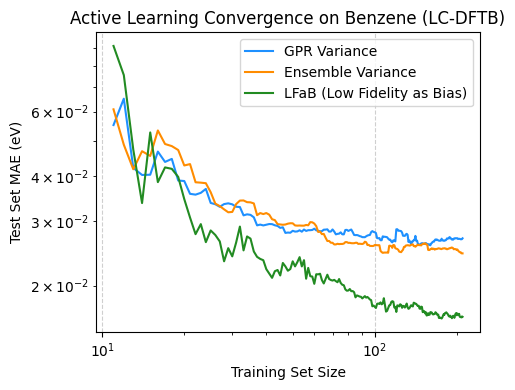

In [4]:
train_sizes = np.arange(11, 11 + n_iters)

plt.figure(figsize=(5, 4))

plt.loglog(train_sizes, maes_gpr, label="GPR Variance", color="dodgerblue")
plt.loglog(train_sizes, maes_ens, label="Ensemble Variance", color="darkorange")
plt.loglog(
    train_sizes, maes_lfab, label="LFaB (Low Fidelity as Bias)", color="forestgreen"
)

plt.xlabel("Training Set Size")
plt.ylabel("Test Set MAE (eV)")
plt.title("Active Learning Convergence on Benzene (LC-DFTB)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()